# CardioAI — Exploratory Data Analysis

**Milestone 2: EDA**
Dataset: `CardioAI_Merged_Heart_Dataset.csv` (merged UCI Heart Disease sources)

Goals:
- Understand structure, types, and data quality
- Check for missing values, duplicates, and outliers
- Examine class balance for the `target` variable
- Visualize feature distributions and relationships with heart disease risk
- Surface candidate features and red flags to carry into preprocessing


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("../data/CardioAI_Merged_Heart_Dataset.csv")
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Dataset shape: 599 rows x 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1.0,0.0,125.0,212.0,0.0,1.0,168.0,0.0,1.0,2.0,2.0,3.0,0
1,53.0,1.0,0.0,140.0,203.0,1.0,0.0,155.0,1.0,3.1,0.0,0.0,3.0,0
2,70.0,1.0,0.0,145.0,174.0,0.0,1.0,125.0,1.0,2.6,0.0,0.0,3.0,0
3,61.0,1.0,0.0,148.0,203.0,0.0,1.0,161.0,0.0,0.0,2.0,1.0,3.0,0
4,62.0,0.0,0.0,138.0,294.0,1.0,1.0,106.0,0.0,1.9,1.0,3.0,2.0,0


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       599 non-null    float64
 1   sex       599 non-null    float64
 2   cp        599 non-null    float64
 3   trestbps  599 non-null    float64
 4   chol      599 non-null    float64
 5   fbs       599 non-null    float64
 6   restecg   599 non-null    float64
 7   thalach   599 non-null    float64
 8   exang     599 non-null    float64
 9   oldpeak   599 non-null    float64
 10  slope     599 non-null    float64
 11  ca        599 non-null    float64
 12  thal      599 non-null    float64
 13  target    599 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 65.6 KB


In [3]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,599.0,54.480801,9.041481,29.0,48.0,56.0,61.0,77.0
sex,599.0,0.679466,0.467072,0.0,0.0,1.0,1.0,1.0
cp,599.0,2.051753,1.484252,0.0,1.0,2.0,3.0,4.0
trestbps,599.0,131.647746,17.647831,94.0,120.0,130.0,140.0,200.0
chol,599.0,246.921536,51.833011,126.0,211.0,242.0,275.0,564.0
fbs,599.0,0.146912,0.354314,0.0,0.0,0.0,0.0,1.0
restecg,599.0,0.759599,0.827397,0.0,0.0,1.0,1.5,2.0
thalach,599.0,149.584307,22.903224,71.0,133.0,153.0,166.0,202.0
exang,599.0,0.327212,0.469588,0.0,0.0,0.0,1.0,1.0
oldpeak,599.0,1.049249,1.162814,0.0,0.0,0.8,1.6,6.2


## Data Quality Checks

Missing values, duplicate rows, and basic sanity checks on categorical ranges.

In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")


Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate rows: 0


In [5]:
# Feature groups based on the UCI Heart Disease schema
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

print("Categorical feature value ranges:\n")
for col in categorical_features:
    print(f"{col}: {sorted(df[col].unique())}")


Categorical feature value ranges:

sex: [np.float64(0.0), np.float64(1.0)]
cp: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
fbs: [np.float64(0.0), np.float64(1.0)]
restecg: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
exang: [np.float64(0.0), np.float64(1.0)]
slope: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]
ca: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
thal: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(6.0), np.float64(7.0)]


**Notes on the feature schema** (standard UCI Heart Disease attributes):
- `age` — age in years
- `sex` — 1 = male, 0 = female
- `cp` — chest pain type (0–4)
- `trestbps` — resting blood pressure (mm Hg)
- `chol` — serum cholesterol (mg/dl)
- `fbs` — fasting blood sugar > 120 mg/dl (1 = true)
- `restecg` — resting ECG results (0–2)
- `thalach` — maximum heart rate achieved
- `exang` — exercise-induced angina (1 = yes)
- `oldpeak` — ST depression induced by exercise relative to rest
- `slope` — slope of the peak exercise ST segment
- `ca` — number of major vessels colored by fluoroscopy (0–4)
- `thal` — thalassemia indicator
- `target` — 1 = heart disease present, 0 = absent


## Target Distribution

Checking class balance — this determines whether we need class-weighting or resampling later.

/tmp/ipykernel_572/2551929950.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="target", ax=ax[0], palette=["#4C72B0", "#C44E52"])
/tmp/ipykernel_572/2551929950.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(["No Disease (0)", "Disease (1)"])


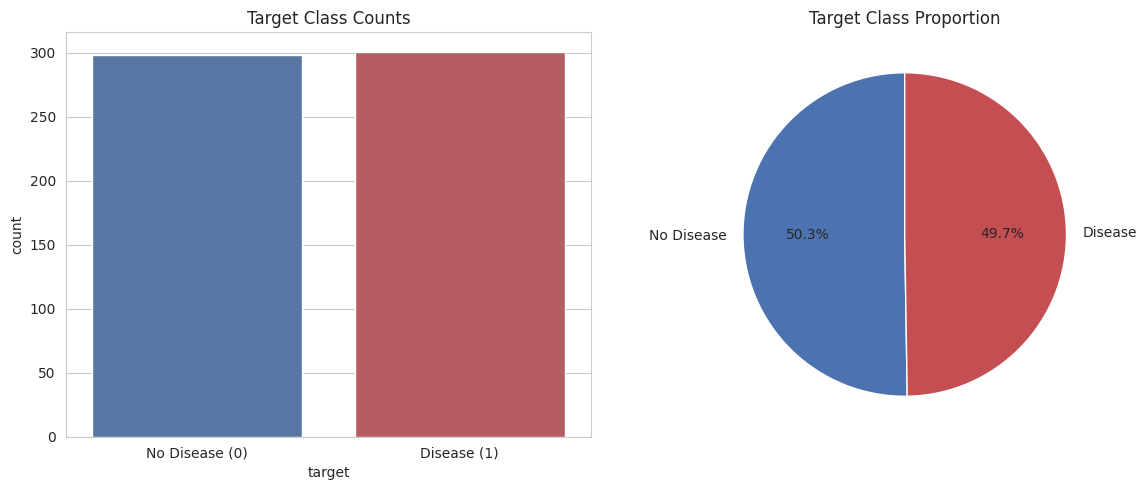

target
1    301
0    298
Name: count, dtype: int64

Class balance: 50.3% positive, 49.7% negative — well balanced.


In [6]:
target_counts = df["target"].value_counts()
target_pct = (target_counts / len(df) * 100).round(1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x="target", ax=ax[0], palette=["#4C72B0", "#C44E52"])
ax[0].set_title("Target Class Counts")
ax[0].set_xticklabels(["No Disease (0)", "Disease (1)"])

ax[1].pie(target_counts, labels=["No Disease", "Disease"], autopct="%1.1f%%",
          colors=["#4C72B0", "#C44E52"], startangle=90)
ax[1].set_title("Target Class Proportion")

plt.tight_layout()
plt.savefig("../images/target_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print(target_counts)
print(f"\nClass balance: {target_pct[1]}% positive, {target_pct[0]}% negative — well balanced.")


## Numeric Feature Distributions

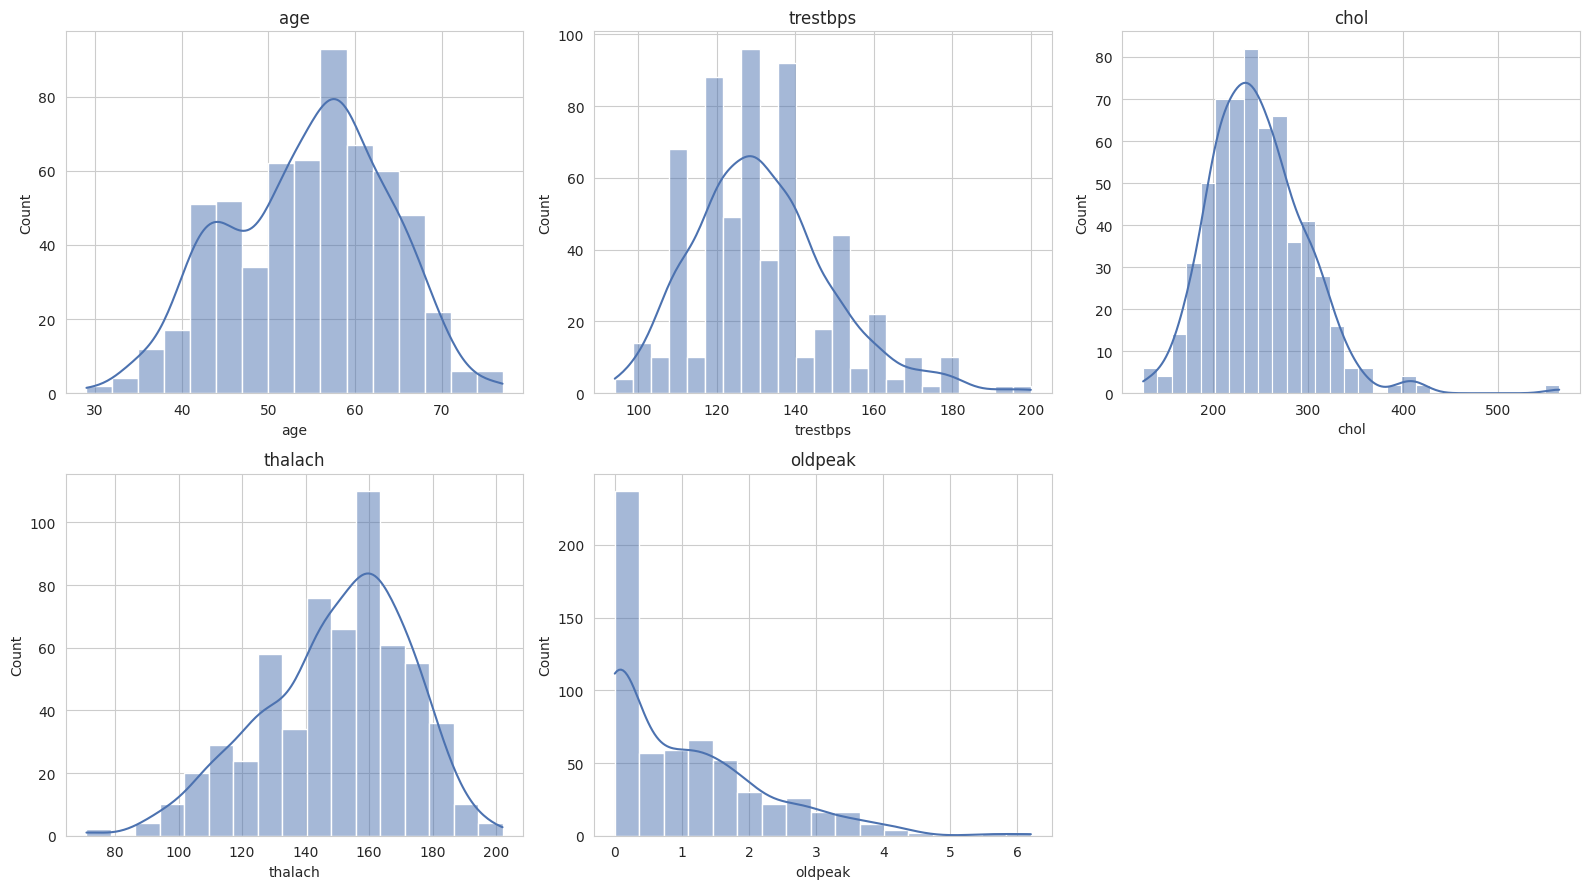

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(col)

for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("../images/numeric_distributions.png", dpi=120, bbox_inches="tight")
plt.show()


/tmp/ipykernel_572/3758532856.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["target"], y=df[col], ax=axes[i], palette=["#4C72B0", "#C44E52"])
/tmp/ipykernel_572/3758532856.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No Disease", "Disease"])
/tmp/ipykernel_572/3758532856.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["target"], y=df[col], ax=axes[i], palette=["#4C72B0", "#C44E52"])
/tmp/ipykernel_572/3758532856.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].s

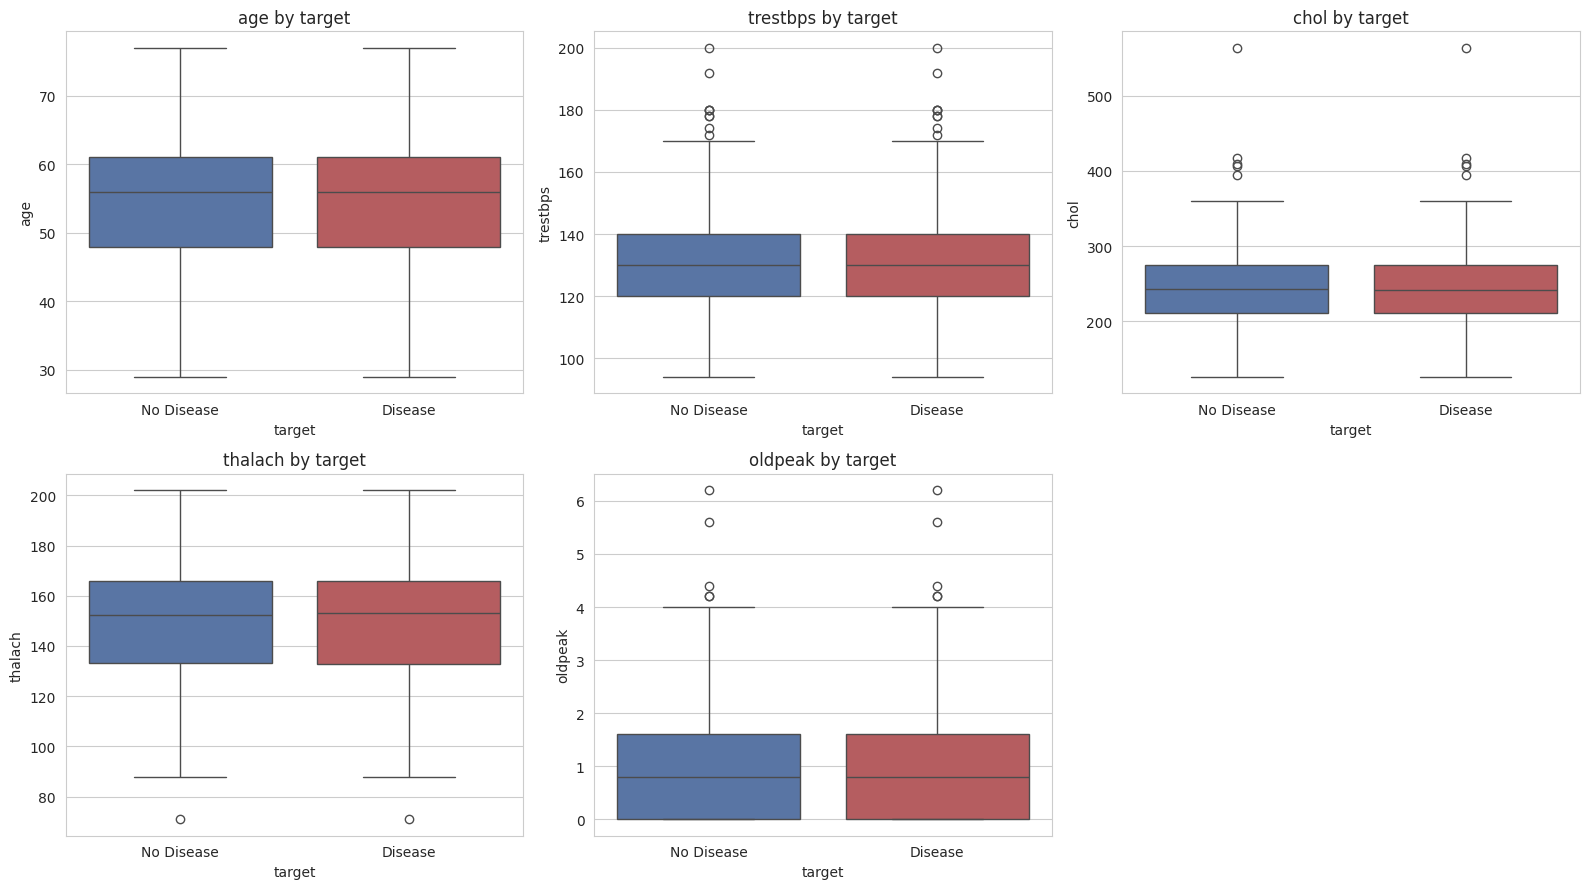

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(x=df["target"], y=df[col], ax=axes[i], palette=["#4C72B0", "#C44E52"])
    axes[i].set_title(f"{col} by target")
    axes[i].set_xticklabels(["No Disease", "Disease"])

for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("../images/numeric_by_target.png", dpi=120, bbox_inches="tight")
plt.show()


## Categorical Feature Relationships with Target

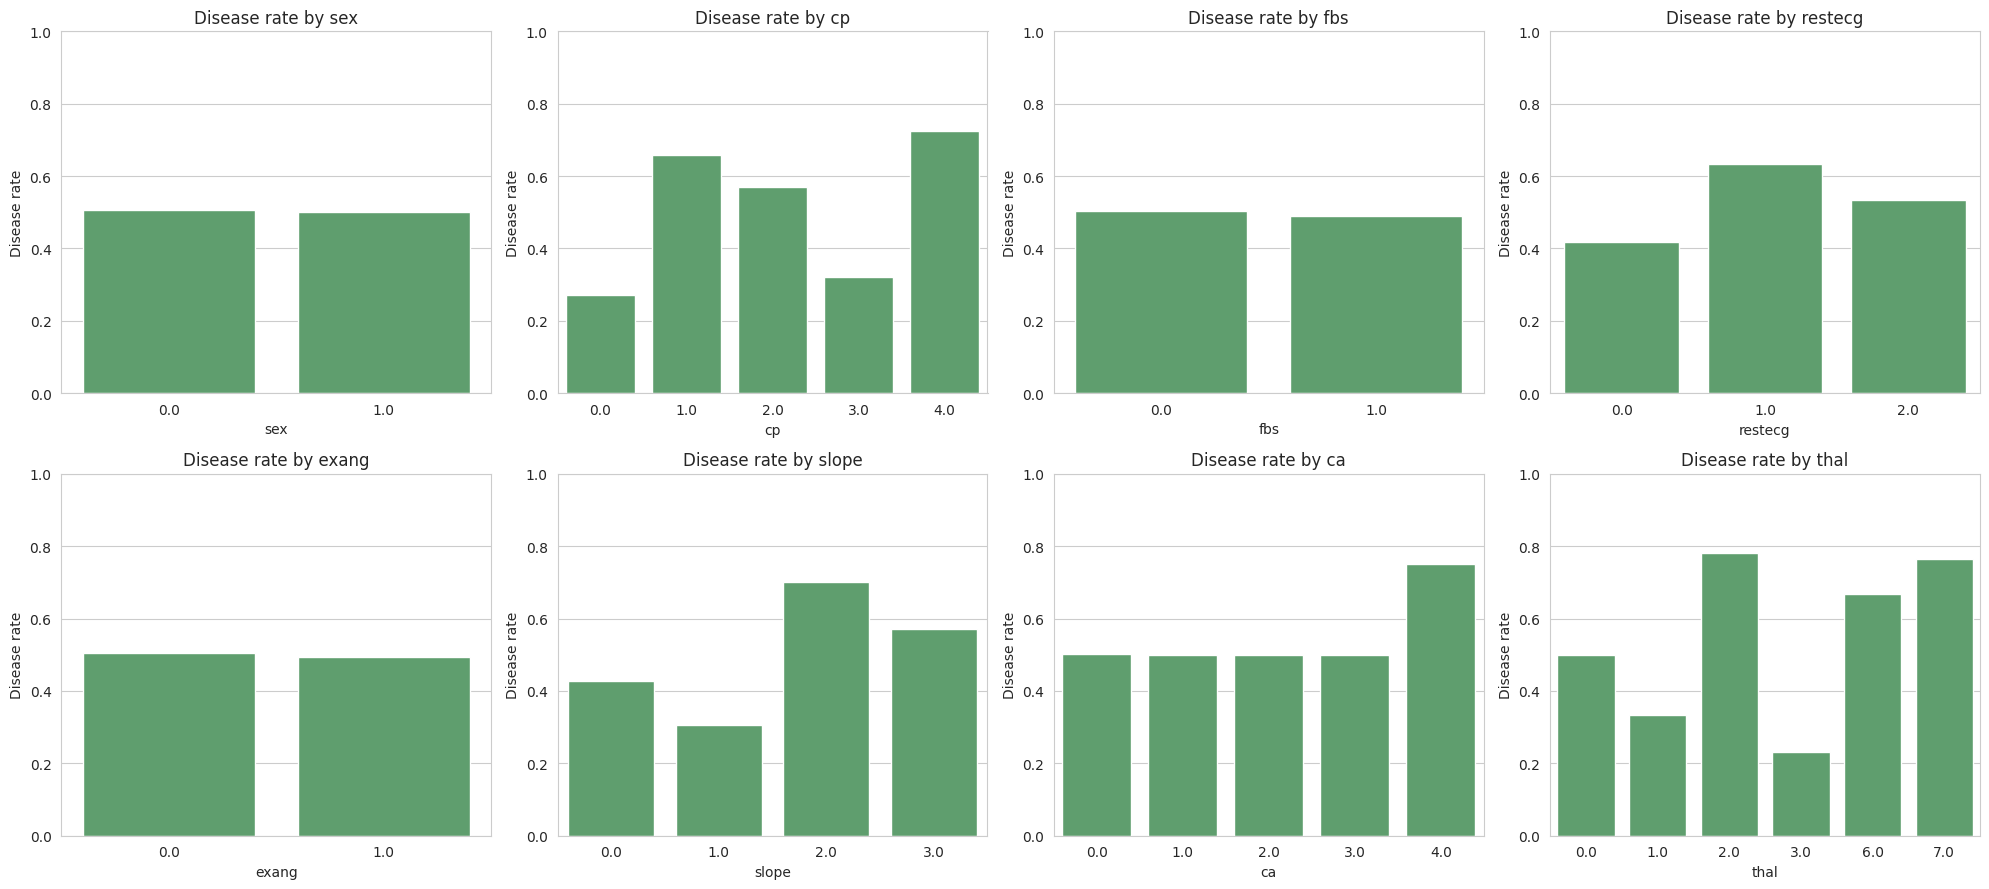

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    rate = df.groupby(col)["target"].mean().reset_index()
    sns.barplot(data=rate, x=col, y="target", ax=axes[i], color="#55A868")
    axes[i].set_title(f"Disease rate by {col}")
    axes[i].set_ylabel("Disease rate")
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("../images/categorical_disease_rates.png", dpi=120, bbox_inches="tight")
plt.show()


## Correlation Analysis

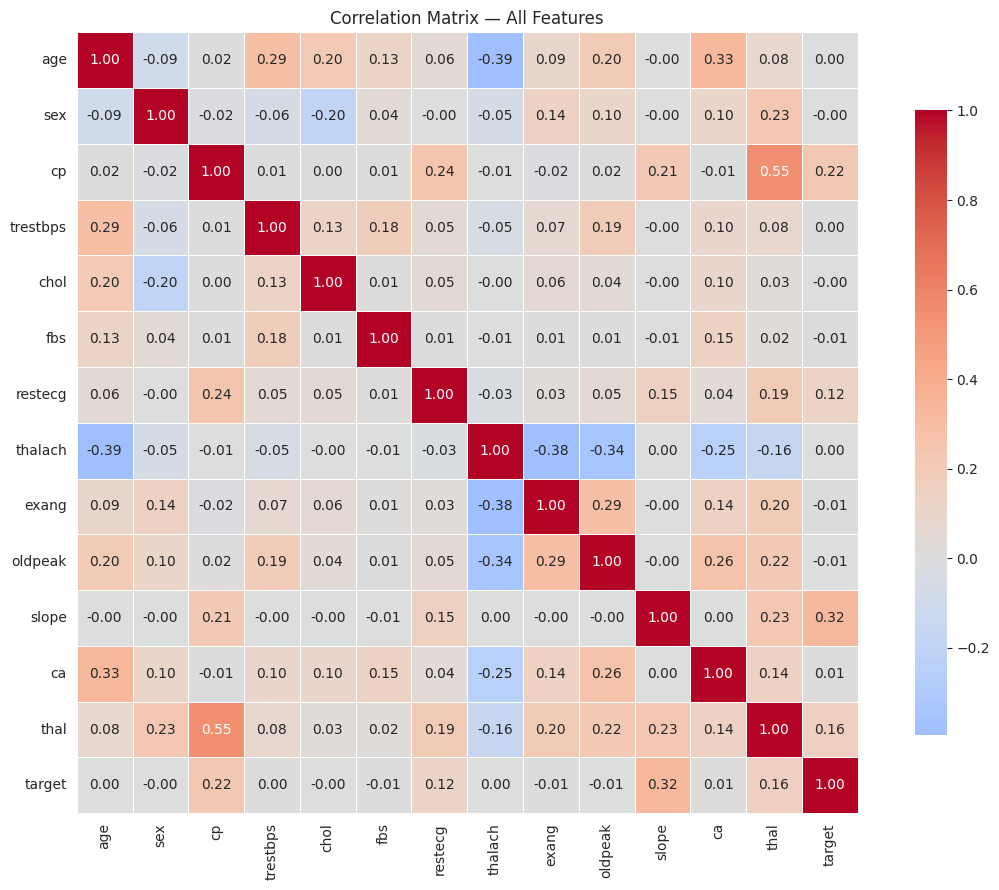

In [10]:
plt.figure(figsize=(12, 9))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix — All Features")
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


In [11]:
target_corr = corr["target"].drop("target").sort_values(key=abs, ascending=False)
print("Features ranked by correlation strength with target:\n")
print(target_corr)


Features ranked by correlation strength with target:

slope       0.319370
cp          0.221594
thal        0.160026
restecg     0.118583
fbs        -0.011510
exang      -0.010609
ca          0.010141
oldpeak    -0.005529
sex        -0.003715
trestbps    0.003035
chol       -0.001701
thalach     0.001039
age         0.000473
Name: target, dtype: float64


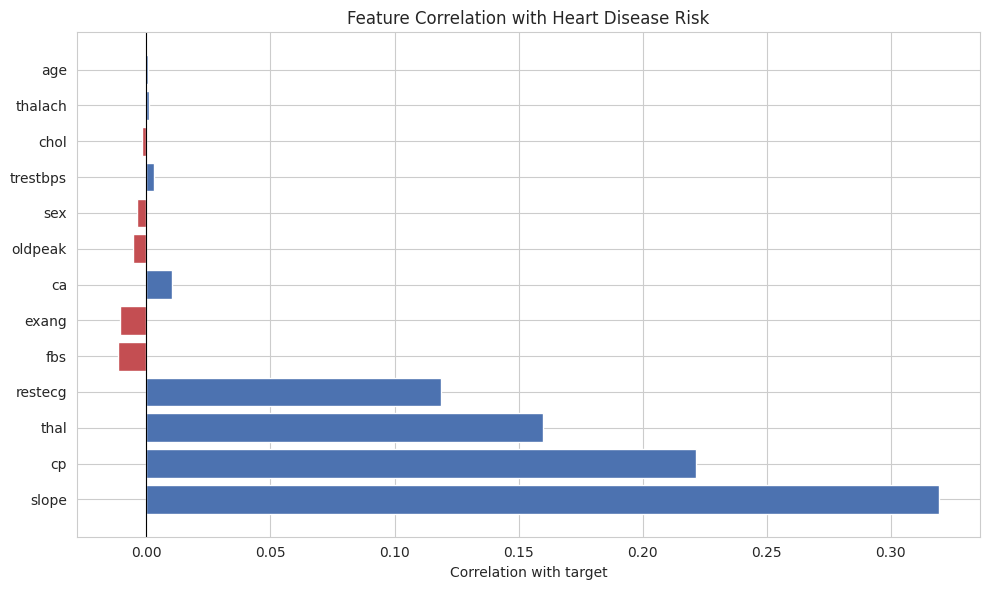

In [12]:
plt.figure(figsize=(10, 6))
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Correlation with target")
plt.title("Feature Correlation with Heart Disease Risk")
plt.tight_layout()
plt.savefig("../images/target_correlation_ranked.png", dpi=120, bbox_inches="tight")
plt.show()


## Outlier Check

Quick IQR-based outlier scan on numeric features — informs whether we need outlier handling in preprocessing.

In [13]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_summary = pd.DataFrame({
    "feature": numeric_features,
    "outlier_count": [iqr_outlier_count(df[col]) for col in numeric_features],
})
outlier_summary["outlier_pct"] = (outlier_summary["outlier_count"] / len(df) * 100).round(2)
outlier_summary.sort_values("outlier_count", ascending=False)


,feature,outlier_count,outlier_pct
1,trestbps,18,3.01
4,oldpeak,10,1.67
2,chol,10,1.67
3,thalach,2,0.33
0,age,0,0.00


## EDA Summary

| Check | Result |
|---|---|
| Rows / columns | 599 rows, 14 columns (13 features + target) |
| Missing values | None |
| Duplicate rows | None |
| Class balance | 301 positive / 298 negative — well balanced, no resampling needed |
| Correlation strength | Notably weaker than the classic single-source UCI dataset — the strongest linear correlate is `slope` (r ≈ 0.32), followed by `cp` (r ≈ 0.22) and `thal` (r ≈ 0.16); most other features (including `age`, `chol`, `thalach`, `oldpeak`) show near-zero linear correlation with `target` |
| Outliers | Present in a few numeric columns (`chol`, `trestbps`, `oldpeak`) at low rates |

**Interpretation:** the weak linear correlations don't necessarily mean these features are unpredictive — heart disease risk is driven by non-linear interactions between variables (e.g. age combined with cholesterol, or chest pain type combined with exercise-induced angina), which a simple Pearson correlation can't capture. This is exactly the kind of pattern tree-based models (Random Forest, XGBoost) are built to find, which is why the model comparison in Notebook 03 matters more here than the correlation ranking alone.

**Carried into preprocessing (Notebook 02):**
- No imputation needed — dataset is already clean
- `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal` are categorical/ordinal codes — kept as numeric (already encoded) but candidates for one-hot encoding on the nominal ones (`cp`, `restecg`, `slope`, `thal`)
- `age`, `trestbps`, `chol`, `thalach`, `oldpeak` are continuous — require scaling
- Balanced target means standard train/test split is sufficient; stratification still applied as best practice
